# Lab 11 — Advanced Exploratory Data Analysis, Colab Version with Visuals, ARM, and Clear Interpretations
## Chile Voting Intentions Dataset

This notebook completes the Lab 11 EDA task using the Chile voting intentions dataset. It is designed to run in **Google Colab** as well as locally.

**How to run in Google Colab**

1. Upload this `.ipynb` file to Google Colab.
2. Choose **Runtime → Run all**.
3. The notebook will automatically check/install required packages and load the public Chile dataset if `data/chile.csv` is not present.

**What was added beyond the basic lab requirements**

- missing-data checks and a missingness heatmap
- categorical count tables with percentages
- robust descriptive statistics for income: IQR, MAD, skewness, kurtosis, trimmed mean
- bootstrap confidence intervals for income mean and median
- outlier detection using the 1.5 × IQR boxplot rule
- chi-square test and Cramér's V for education vs. vote
- Pearson and Spearman correlations
- expanded visual EDA: stacked percentage bars, mosaic plot, grouped boxplots/violins, pairplot, and ARM rule graphics
- Association Rule Mining / ARM for interpretable survey patterns
- logistic regression and predictive evaluation for `Yes` vs. `No` vote

**Dataset note.** The notebook first checks for `data/chile.csv`. If that file is missing, it loads the public Rdatasets copy of `carData::Chile` directly from GitHub. Rdatasets adds an artificial `rownames` column, which is removed before analysis.

**Readability note.** The interpretation cells are written in plain language. They focus on what each result means, not on unnecessary mathematical detail.


In [1]:
# Google Colab / local setup
# This cell checks for required packages and installs any that are missing.
# In Google Colab, most of these packages are already available, so this usually runs quickly.

import sys
import subprocess
import importlib.util
from pathlib import Path

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scipy': 'scipy',
    'statsmodels': 'statsmodels',
    'sklearn': 'scikit-learn',
    'networkx': 'networkx',
}

missing_packages = [pip_name for import_name, pip_name in required_packages.items()
                    if importlib.util.find_spec(import_name) is None]

if missing_packages:
    print('Installing missing packages:', missing_packages)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing_packages])
else:
    print('All required packages are already installed.')

print('Running in Google Colab:', IN_COLAB)


All required packages are already installed.
Running in Google Colab: False


In [2]:
# Core packages
from pathlib import Path
from itertools import combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from statsmodels.graphics.mosaicplot import mosaic

# Statistical tests and models
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, kruskal, median_abs_deviation
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Simple predictive model evaluation
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

RANDOM_STATE = 42
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')


## 1. Import the data

This Colab-ready version first looks for `data/chile.csv`. If that file is not present, it downloads the public Rdatasets copy from GitHub.

This means the notebook can be run in two ways:

- **Colab:** upload only the `.ipynb` and run all cells; the dataset is loaded from the public URL.
- **Local/offline package:** keep the included `data/chile.csv` file next to the notebook.

In [3]:
local_path = Path('data/chile.csv')
remote_url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/carData/Chile.csv'

try:
    if local_path.exists():
        df = pd.read_csv(local_path)
        data_source = f'local file: {local_path}'
    else:
        df = pd.read_csv(remote_url)
        data_source = 'public Rdatasets URL'
except Exception as exc:
    raise RuntimeError(
        'Could not load the Chile dataset. In Colab, check that internet access is enabled. '
        'Alternatively, upload the CSV as data/chile.csv and rerun this cell.'
    ) from exc

# Rdatasets exports include an artificial row index column. It is not a survey variable,
# so it must be removed before numeric summaries, correlations, and modelling.
if 'rownames' in df.columns:
    df = df.drop(columns=['rownames'])

print('Data source:', data_source)
print('Cleaned shape:', df.shape)
df.head()


Data source: local file: data/chile.csv
Cleaned shape: (2700, 8)


,region,population,sex,age,education,income,statusquo,vote
0,N,175000,M,65.0,P,35000.0,1.00820,Y
1,N,175000,M,29.0,PS,7500.0,-1.29617,N
2,N,175000,F,38.0,P,15000.0,1.23072,Y
3,N,175000,F,49.0,P,35000.0,-1.03163,N
4,N,175000,F,23.0,S,35000.0,-1.10496,N


### Interpretation: data import and structure

The data loaded correctly. After removing the artificial `rownames` column, the dataset has **2700 rows and 8 real variables**.

This is the correct structure for the rest of the notebook, because `rownames` is only an index from the public data source and should not be analyzed as a real variable.


In [4]:
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nData types:')
print(df.dtypes)

Shape: (2700, 8)

Columns: ['region', 'population', 'sex', 'age', 'education', 'income', 'statusquo', 'vote']

Data types:
region         object
population      int64
sex            object
age           float64
education      object
income        float64
statusquo     float64
vote           object
dtype: object


### Variable guide

The dataset contains survey responses about voting intentions in the 1988 Chilean plebiscite context.

| Variable | Type | Meaning used in this analysis |
|---|---:|---|
| `region` | categorical | respondent region code |
| `population` | quantitative | population size of respondent's area |
| `sex` | categorical | `F` or `M` |
| `age` | quantitative | age in years |
| `education` | categorical | `P` = primary, `S` = secondary, `PS` = post-secondary |
| `income` | quantitative | monthly income |
| `statusquo` | quantitative | scale measuring support for the status quo |
| `vote` | categorical | `Y` = yes, `N` = no, `U` = undecided, `A` = abstain |

## 2. General overview

This section corresponds to the basic Lab 11 requirements: `head()`, shape, `info()`, `describe()`, category counts, and grouped statistics.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      2700 non-null   object 
 1   population  2700 non-null   int64  
 2   sex         2700 non-null   object 
 3   age         2699 non-null   float64
 4   education   2689 non-null   object 
 5   income      2602 non-null   float64
 6   statusquo   2683 non-null   float64
 7   vote        2532 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 168.9+ KB


In [6]:
# Numeric summary
numeric_summary = df.describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
population,2700.0,1.522222e+05,102198.039602,3750.00000,25000.000000,175000.00000,250000.000000,250000.00000
age,2699.0,3.854872e+01,14.756415,18.00000,26.000000,36.00000,49.000000,70.00000
income,2602.0,3.387586e+04,39502.867120,2500.00000,7500.000000,15000.00000,35000.000000,200000.00000
statusquo,2683.0,-1.118151e-08,1.000186,-1.80301,-1.002235,-0.04558,0.968575,2.04859


In [7]:
# Missing values table
missing = (
    df.isna().sum()
      .to_frame('missing_count')
      .assign(missing_percent=lambda x: 100 * x['missing_count'] / len(df))
      .sort_values('missing_percent', ascending=False)
)
missing

,missing_count,missing_percent
vote,168,6.222222
income,98,3.629630
statusquo,17,0.629630
education,11,0.407407
age,1,0.037037
sex,0,0.000000
region,0,0.000000
population,0,0.000000


### Interpretation: missing values

The dataset is mostly complete. The largest amount of missing data is in `vote`: **168 missing responses**, or **6.22%** of the sample. The next largest is `income`, with **98 missing values**, or **3.63%**.

These percentages are small enough that the dataset is still useful for EDA. However, any analysis involving `vote` or `income` uses slightly fewer observations because rows with missing values must be dropped for those steps.


### Missing-data pattern heatmap

The table above gives the amount of missingness per variable. The heatmap below shows whether missing values appear scattered across observations or concentrated in particular parts of the dataset.

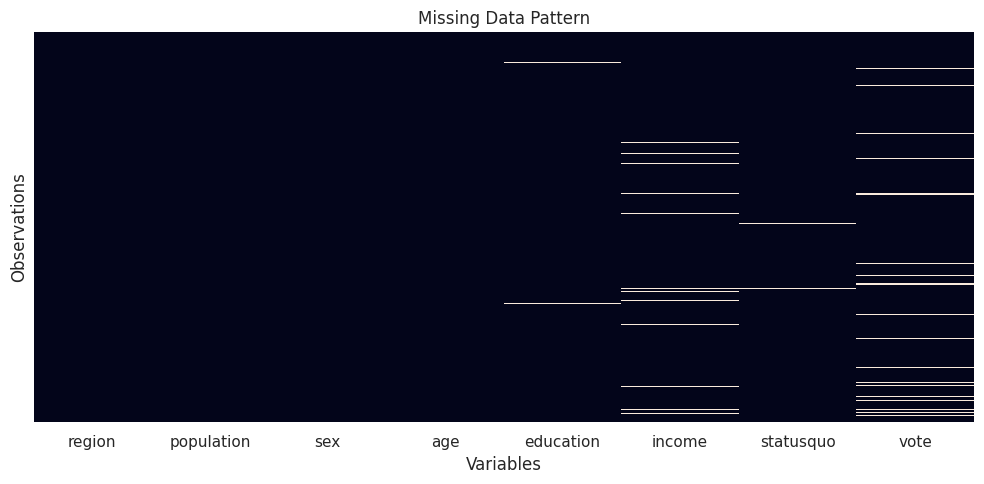

In [8]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title('Missing Data Pattern')
plt.xlabel('Variables')
plt.ylabel('Observations')
plt.tight_layout()
plt.show()

### Comment on the missing-data heatmap

The heatmap supports the missing-value table. Missing values are scattered rather than concentrated in one large block.

This is reassuring: there is no obvious visual sign that a whole section of the dataset failed to load or that many variables are missing together.


In [9]:
# Categorical count tables with percentages
categorical_cols = ['region', 'sex', 'education', 'vote']

for col in categorical_cols:
    table = df[col].value_counts(dropna=False).rename_axis(col).to_frame('count')
    table['percent'] = 100 * table['count'] / len(df)
    print(f'\n{col.upper()}')
    display(table)


REGION


,count,percent
region,,
SA,960,35.555556
S,718,26.592593
C,600,22.222222
N,322,11.925926
M,100,3.703704



SEX


,count,percent
sex,,
F,1379,51.074074
M,1321,48.925926



EDUCATION


,count,percent
education,,
S,1120,41.481481
P,1107,41.000000
PS,462,17.111111
NaN,11,0.407407



VOTE


,count,percent
vote,,
N,889,32.925926
Y,868,32.148148
U,588,21.777778
A,187,6.925926
NaN,168,6.222222


### Interpretation: categorical variables

The sample is almost balanced by sex: **51.1% female** and **48.9% male**.

Education is mostly **Secondary (41.5%)** and **Primary (41.0%)**, while **Post-secondary (17.1%)** is smaller.

Vote intention is mainly split between **No (32.9%)** and **Yes (32.1%)**, with a large **Undecided (21.8%)** group. This makes vote intention a useful outcome for exploring differences across groups.


In [10]:
# Average income by region and by education/vote groups
income_by_region = df.groupby('region', dropna=False)['income'].agg(['count', 'mean', 'median', 'std']).sort_values('mean', ascending=False)
income_by_education_vote = df.groupby(['education', 'vote'], dropna=False)['income'].agg(['count', 'mean', 'median']).round(2)

display(income_by_region.round(2))
display(income_by_education_vote)

,count,mean,median,std
region,,,,
SA,919,42442.87,35000.0,47670.01
C,579,31321.24,15000.0,36700.57
N,314,30764.33,15000.0,29420.88
S,697,27087.52,15000.0,33005.30
M,93,26505.38,15000.0,24143.31


count      mean   median
education vote                          
P         A        49  19489.80  15000.0
          N       262  16650.76  15000.0
          U       286  16783.22  15000.0
          Y       410  18469.51  15000.0
          NaN      65  20038.46  15000.0
PS        A        31  48467.74  35000.0
          N       220  63238.64  35000.0
          U        48  58281.25  35000.0
          Y       123  88252.03  75000.0
          NaN      23  58152.17  35000.0
S         A        99  35176.77  35000.0
          N       385  36071.43  35000.0
          U       223  30325.11  15000.0
          Y       304  39975.33  35000.0
          NaN      65  35538.46  15000.0
NaN       N         2   8750.00   8750.0
          U         3   7500.00   7500.0
          Y         4  28125.00  15000.0
          NaN       0       NaN      NaN

### Interpretation: grouped income summaries

The grouped income summaries show that income differs across regions and education/vote groups.

However, income is strongly skewed, so the **median** is usually a better description of a typical respondent than the mean. Very high incomes pull the mean upward.


## 3. Data preparation for analysis

For EDA, I keep the original data but also add more readable labels for plots and create a log-income variable. The log transformation is useful because income is usually right-skewed.

In [11]:
df_clean = df.copy()

vote_labels = {'Y': 'Yes', 'N': 'No', 'U': 'Undecided', 'A': 'Abstain'}
education_labels = {'P': 'Primary', 'S': 'Secondary', 'PS': 'Post-secondary'}
sex_labels = {'F': 'Female', 'M': 'Male'}

# Map labels while preserving missing values
df_clean['vote_label'] = df_clean['vote'].map(vote_labels)
df_clean['education_label'] = df_clean['education'].map(education_labels)
df_clean['sex_label'] = df_clean['sex'].map(sex_labels)
df_clean['log_income'] = np.log1p(df_clean['income'])

df_clean[['region', 'sex_label', 'age', 'education_label', 'income', 'log_income', 'statusquo', 'vote_label']].head()

,region,sex_label,age,education_label,income,log_income,statusquo,vote_label
0,N,Male,65.0,Primary,35000.0,10.463132,1.00820,Yes
1,N,Male,29.0,Post-secondary,7500.0,8.922792,-1.29617,No
2,N,Female,38.0,Primary,15000.0,9.615872,1.23072,Yes
3,N,Female,49.0,Primary,35000.0,10.463132,-1.03163,No
4,N,Female,23.0,Secondary,35000.0,10.463132,-1.10496,No


### Comment on data preparation

The new label columns make the plots easier to understand. For example, `Y` becomes `Yes`, `N` becomes `No`, and education codes become readable labels.

`log_income` is added because raw income has a long right tail. The log transformation makes income patterns easier to see in plots.


## 4. Univariate non-graphical EDA: income

Income is the selected quantitative variable. This section computes central tendency, dispersion, and distribution-shape indicators.

In [12]:
income = df_clean['income'].dropna()
q1, q3 = income.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = income[(income < lower_fence) | (income > upper_fence)]

income_stats = pd.Series({
    'count': income.count(),
    'mean': income.mean(),
    'trimmed_mean_10pct': stats.trim_mean(income, proportiontocut=0.10),
    'median': income.median(),
    'mode': income.mode().iloc[0],
    'variance': income.var(ddof=1),
    'standard_deviation': income.std(ddof=1),
    'MAD_robust': median_abs_deviation(income, scale='normal'),
    'minimum': income.min(),
    'Q1': q1,
    'Q3': q3,
    'IQR': iqr,
    'maximum': income.max(),
    'skewness': income.skew(),
    'excess_kurtosis': income.kurtosis(),
    'lower_outlier_fence': lower_fence,
    'upper_outlier_fence': upper_fence,
    'boxplot_outlier_count': outliers.count(),
    'boxplot_outlier_percent': 100 * outliers.count() / income.count()
}).to_frame('income')

income_stats.round(3)

,income
count,2.602000e+03
mean,3.387586e+04
trimmed_mean_10pct,2.574208e+04
median,1.500000e+04
mode,1.500000e+04
variance,1.560477e+09
standard_deviation,3.950287e+04
MAD_robust,1.853253e+04
minimum,2.500000e+03
Q1,7.500000e+03


### Interpretation: income descriptive statistics

Income is clearly **right-skewed**. The mean income is about **33,876**, but the median and mode are both **15,000**.

This means a smaller number of high-income respondents pull the average upward. The skewness (**2.588**), excess kurtosis (**7.316**), and **164 boxplot outliers** all support the same conclusion: income is not normally distributed and has a long upper tail.


In [13]:
# Bootstrap confidence intervals for income mean and median
B = 5000
sample = income.to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
boot_indices = rng.integers(0, len(sample), size=(B, len(sample)))
boot_samples = sample[boot_indices]
boot_mean = boot_samples.mean(axis=1)
boot_median = np.median(boot_samples, axis=1)

ci_table = pd.DataFrame({
    'estimate': [income.mean(), income.median()],
    'ci_lower_2.5%': [np.percentile(boot_mean, 2.5), np.percentile(boot_median, 2.5)],
    'ci_upper_97.5%': [np.percentile(boot_mean, 97.5), np.percentile(boot_median, 97.5)]
}, index=['mean_income', 'median_income'])

ci_table.round(2)

,estimate,ci_lower_2.5%,ci_upper_97.5%
mean_income,33875.86,32357.73,35374.74
median_income,15000.00,15000.00,15000.00


### Interpretation: bootstrap confidence intervals

The bootstrap interval for the **mean income** is about **32,358 to 35,375**. This gives a reasonable range for the average income in the population represented by the sample.

The bootstrap interval for the **median income** stays at **15,000**. That happens because many respondents have exactly that income value, so the sample median is very stable.


## 5. Univariate graphical EDA

The histogram shows the shape of the income distribution. The boxplot highlights the median, quartiles, whiskers, and outliers.

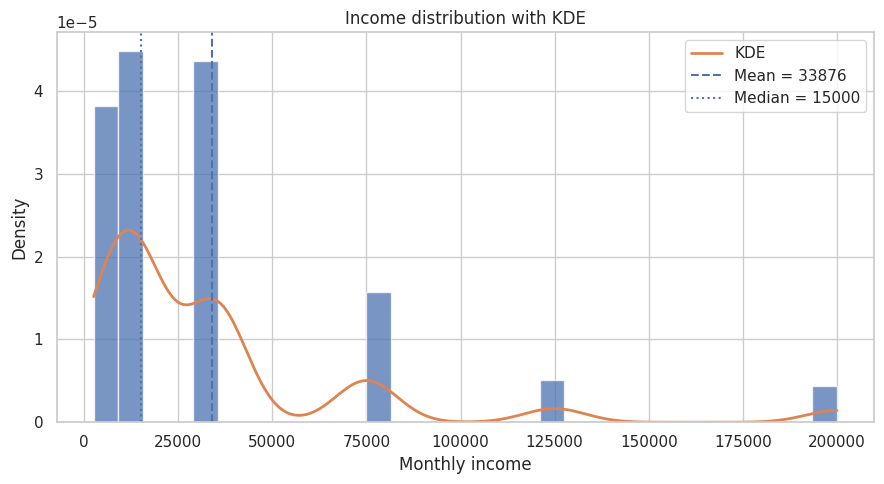

In [14]:
plt.figure(figsize=(9, 5))
plt.hist(income, bins=30, density=True, alpha=0.75)
kde = stats.gaussian_kde(income)
xs = np.linspace(income.min(), income.max(), 300)
plt.plot(xs, kde(xs), linewidth=2, label='KDE')
plt.axvline(income.mean(), linestyle='--', label=f'Mean = {income.mean():.0f}')
plt.axvline(income.median(), linestyle=':', label=f'Median = {income.median():.0f}')
plt.title('Income distribution with KDE')
plt.xlabel('Monthly income')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Comment on the income histogram

The histogram shows many respondents at lower income values and fewer respondents at very high income values.

This matches the numerical results: income is right-skewed, and the mean is higher than the median because of the high-income tail.


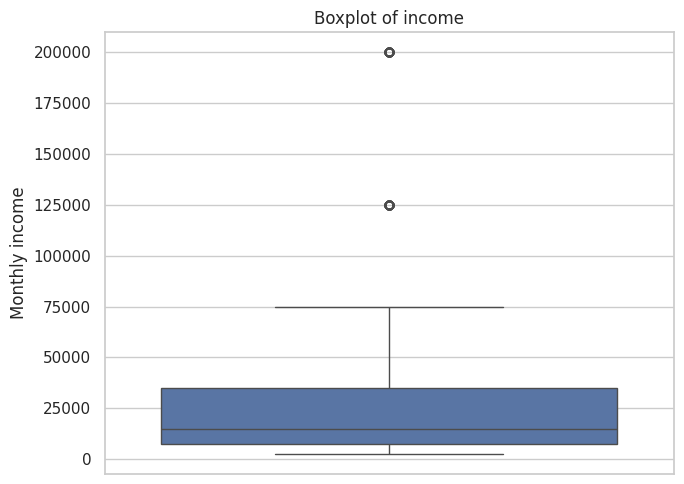

In [15]:
plt.figure(figsize=(7, 5))
sns.boxplot(y=income)
plt.title('Boxplot of income')
plt.ylabel('Monthly income')
plt.tight_layout()
plt.show()

### Comment on the income boxplot

The boxplot shows many high-income outliers above the upper whisker.

This does not mean those values are errors. It means the income distribution is very uneven, so the median and IQR are more reliable than the mean and standard deviation for describing a typical respondent.


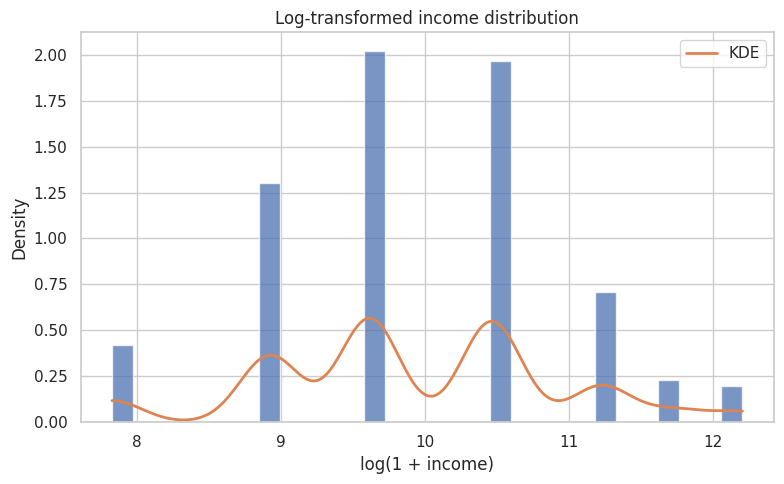

In [16]:
plt.figure(figsize=(8, 5))
log_income = df_clean['log_income'].dropna()
plt.hist(log_income, bins=30, density=True, alpha=0.75)
kde = stats.gaussian_kde(log_income)
xs = np.linspace(log_income.min(), log_income.max(), 300)
plt.plot(xs, kde(xs), linewidth=2, label='KDE')
plt.title('Log-transformed income distribution')
plt.xlabel('log(1 + income)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Comment on the log-income histogram

After applying the log transformation, the income distribution becomes easier to view because the very large values no longer dominate the graph.

This is why log income is useful in later plots and models.


## 6. Multivariate non-graphical EDA

This section examines relationships between variables using cross-tabulation, covariance, correlation, and formal tests.

In [17]:
# Cross-tabulation of education and vote
edu_vote_counts = pd.crosstab(df_clean['education_label'], df_clean['vote_label'], margins=True)
edu_vote_row_pct = pd.crosstab(df_clean['education_label'], df_clean['vote_label'], normalize='index') * 100

display(edu_vote_counts)
display(edu_vote_row_pct.round(2))

vote_label,Abstain,No,Undecided,Yes,All
education_label,,,,,
Post-secondary,32,224,52,130,438
Primary,52,266,296,422,1036
Secondary,103,397,237,311,1048
All,187,887,585,863,2522


vote_label,Abstain,No,Undecided,Yes
education_label,,,,
Post-secondary,7.31,51.14,11.87,29.68
Primary,5.02,25.68,28.57,40.73
Secondary,9.83,37.88,22.61,29.68


### Interpretation: education × vote cross-tabulation

Vote intention differs by education level.

Among **Post-secondary** respondents, **51.1%** report **No** and **29.7%** report **Yes**. Among **Primary** respondents, **40.7%** report **Yes**, **25.7%** report **No**, and **28.6%** are **Undecided**. **Secondary** respondents are in between, with **37.9% No**, **29.7% Yes**, and **22.6% Undecided**.

So education and vote intention appear related, but education alone does not fully explain voting intention.


In [18]:
# Chi-square test for association between education and vote
contingency = pd.crosstab(df_clean['education_label'], df_clean['vote_label'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
n = contingency.to_numpy().sum()
r, k = contingency.shape
cramers_v = np.sqrt((chi2 / n) / min(k - 1, r - 1))

pd.DataFrame({
    'chi_square': [chi2],
    'degrees_of_freedom': [dof],
    'p_value': [p_value],
    'cramers_v': [cramers_v]
}).round(6)

,chi_square,degrees_of_freedom,p_value,cramers_v
0,135.848482,6,0.0,0.164112


### Interpretation: chi-square test for education and vote

The chi-square test confirms that education and vote intention are associated: **χ² = 135.85**, **df = 6**, and **p ≈ 7.53 × 10⁻²⁷**.

The p-value is extremely small, so the differences in the table are unlikely to be random sampling noise. But **Cramér's V = 0.164**, which means the relationship is only small to moderate in strength.

In plain language: education matters, but it is not the strongest variable in the dataset.


### Visualizing categorical relationships

Raw counts are useful, but categorical EDA is often clearer when counts and percentages are visualized. The next plots show how voting intention differs across education levels.

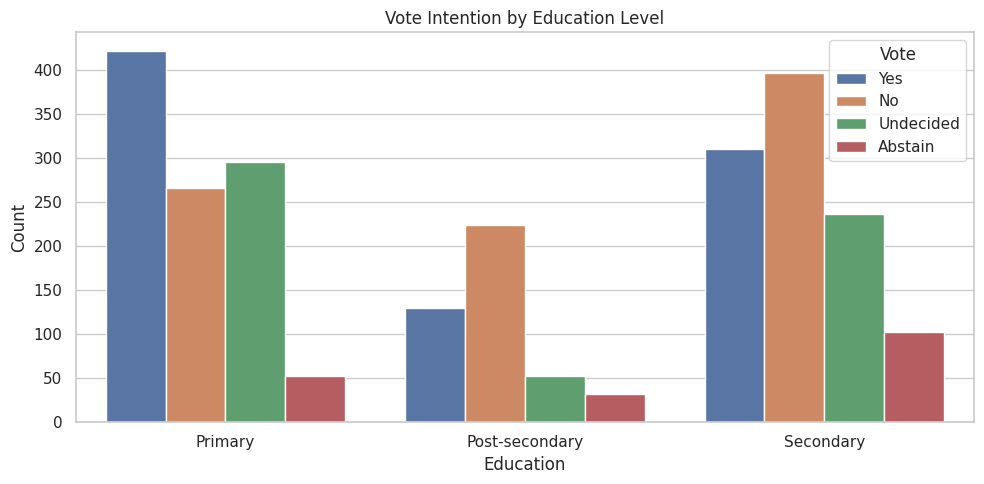

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='education_label', hue='vote_label')
plt.title('Vote Intention by Education Level')
plt.xlabel('Education')
plt.ylabel('Count')
plt.legend(title='Vote')
plt.tight_layout()
plt.show()

### Comment on the education-by-vote count plot

This plot shows the raw number of respondents in each education and vote group.

It is useful for seeing sample size, but it should not be used alone because the education groups are not the same size. The percentage chart below is better for comparing vote patterns within each education level.


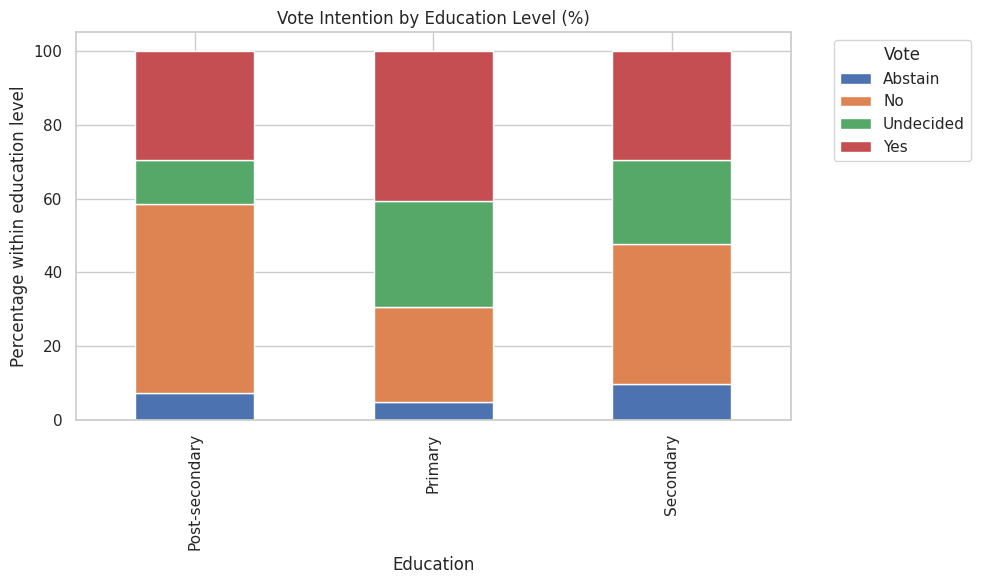

vote_label,Abstain,No,Undecided,Yes
education_label,,,,
Post-secondary,7.3,51.1,11.9,29.7
Primary,5.0,25.7,28.6,40.7
Secondary,9.8,37.9,22.6,29.7


In [20]:
edu_vote_pct = pd.crosstab(df_clean['education_label'], df_clean['vote_label'], normalize='index') * 100

ax = edu_vote_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Vote Intention by Education Level (%)')
plt.xlabel('Education')
plt.ylabel('Percentage within education level')
plt.legend(title='Vote', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

edu_vote_pct.round(1)

### Comment on the stacked percentage chart

This percentage chart is easier to compare than raw counts.

It shows that **Post-secondary** respondents have the largest **No** share, while **Primary** respondents have the largest **Yes** and **Undecided** shares. This agrees with the cross-tabulation.


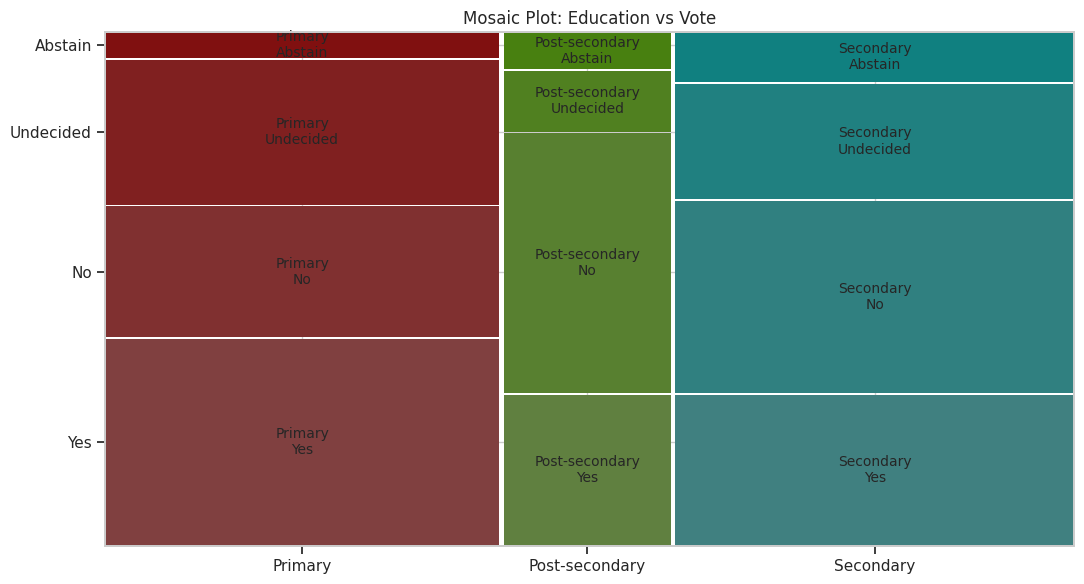

In [21]:
mosaic_data = df_clean[['education_label', 'vote_label']].dropna().copy()
fig, _ = mosaic(
    mosaic_data,
    ['education_label', 'vote_label'],
    title='Mosaic Plot: Education vs Vote'
)
fig.set_size_inches(11, 6)
plt.tight_layout()
plt.show()

### Comment on the mosaic plot

The mosaic plot shows the same education-vote relationship in another visual form.

Wider blocks represent larger education groups. The internal blocks show how each group is split by vote. The plot supports the same conclusion: vote intention changes by education level, but the differences are moderate rather than overwhelming.


In [22]:
# Covariance and correlation for quantitative variables
quant_cols = ['population', 'age', 'income', 'statusquo']

cov_matrix = df_clean[quant_cols].cov()
pearson_corr = df_clean[quant_cols].corr(method='pearson')
spearman_corr = df_clean[quant_cols].corr(method='spearman')

display(cov_matrix.round(3))
display(pearson_corr.round(3))
display(spearman_corr.round(3))

,population,age,income,statusquo
population,1.044444e+10,31645.216,8.897026e+08,-20281.066
age,3.164522e+04,217.752,-1.879906e+04,1.698
income,8.897026e+08,-18799.064,1.560477e+09,1534.467
statusquo,-2.028107e+04,1.698,1.534467e+03,1.000


,population,age,income,statusquo
population,1.000,0.021,0.220,-0.198
age,0.021,1.000,-0.032,0.115
income,0.220,-0.032,1.000,0.039
statusquo,-0.198,0.115,0.039,1.000


,population,age,income,statusquo
population,1.000,0.024,0.239,-0.207
age,0.024,1.000,-0.061,0.106
income,0.239,-0.061,1.000,0.020
statusquo,-0.207,0.106,0.020,1.000


### Interpretation: covariance and correlation matrices

The covariance matrix is hard to compare because the variables use very different units. The correlation matrix is more useful because all correlations are scaled between -1 and 1.

Most numeric correlations are weak. The largest visible relationships are `population` with `income` (**0.220**) and `population` with `statusquo` (**-0.198**). The relationship between `age` and `statusquo` is positive but small (**0.115**).

So the numeric variables do not show strong simple linear relationships with each other.


In [23]:
# Age and statusquo: Pearson and Spearman correlations
age_statusquo = df_clean[['age', 'statusquo']].dropna()
pearson_result = pearsonr(age_statusquo['age'], age_statusquo['statusquo'])
spearman_result = spearmanr(age_statusquo['age'], age_statusquo['statusquo'])

pd.DataFrame({
    'method': ['Pearson', 'Spearman'],
    'correlation': [pearson_result.statistic, spearman_result.statistic],
    'p_value': [pearson_result.pvalue, spearman_result.pvalue]
}).round(6)

,method,correlation,p_value
0,Pearson,0.115069,0.0
1,Spearman,0.106118,0.0


### Interpretation: age and statusquo correlation

Age and `statusquo` have a weak positive relationship: Pearson correlation is about **0.115**, and Spearman correlation is about **0.106**.

The p-values are very small mainly because the sample is large. The effect itself is still small. In plain language: older respondents tend to have slightly higher `statusquo` scores, but age is not a strong predictor by itself.


## 7. Multivariate graphical EDA

This section uses plots to examine relationships between categorical and quantitative variables.

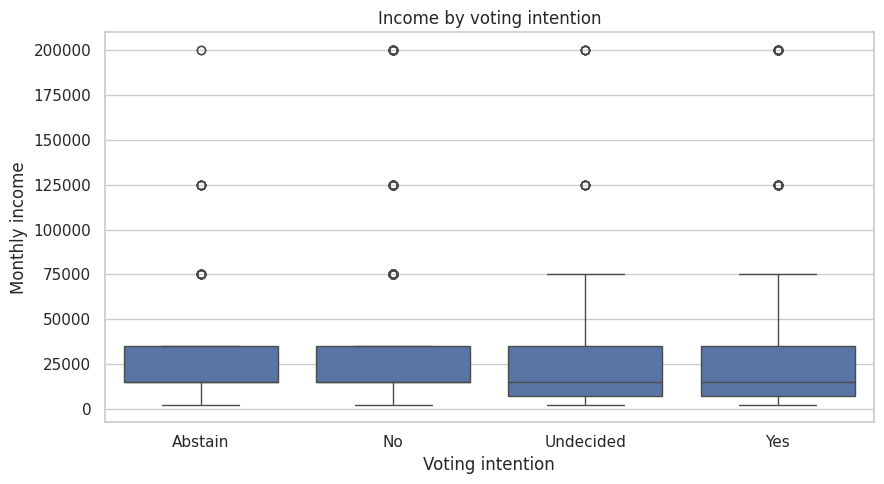

In [24]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x='vote_label', y='income', order=['Abstain', 'No', 'Undecided', 'Yes'])
plt.title('Income by voting intention')
plt.xlabel('Voting intention')
plt.ylabel('Monthly income')
plt.tight_layout()
plt.show()

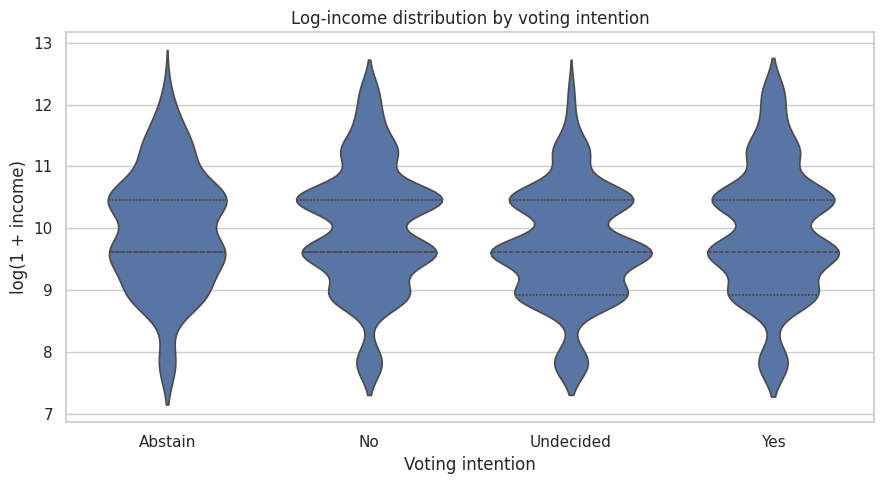

In [25]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df_clean, x='vote_label', y='log_income', order=['Abstain', 'No', 'Undecided', 'Yes'], inner='quartile')
plt.title('Log-income distribution by voting intention')
plt.xlabel('Voting intention')
plt.ylabel('log(1 + income)')
plt.tight_layout()
plt.show()

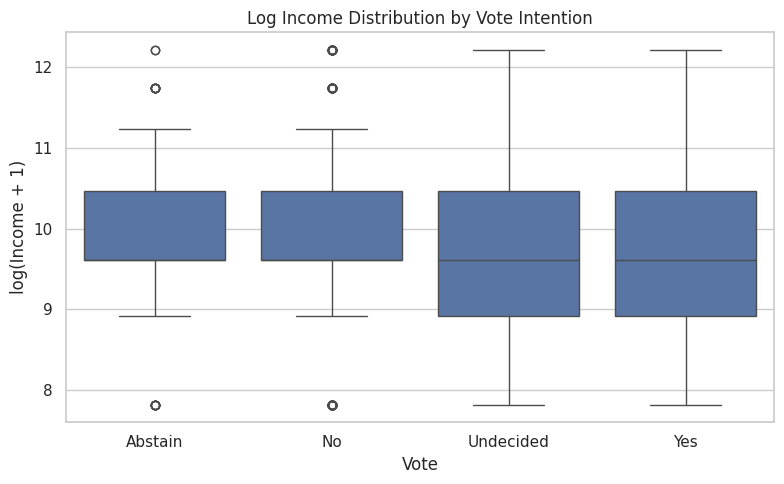

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='vote_label', y='log_income', order=['Abstain', 'No', 'Undecided', 'Yes'])
plt.title('Log Income Distribution by Vote Intention')
plt.xlabel('Vote')
plt.ylabel('log(Income + 1)')
plt.tight_layout()
plt.show()

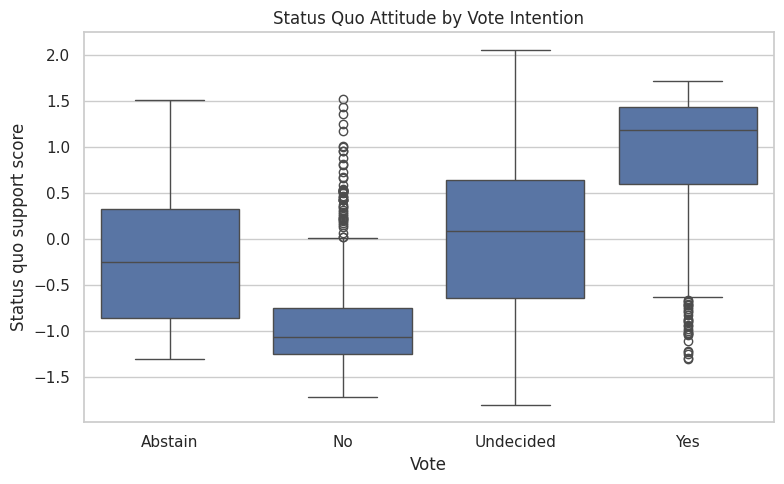

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='vote_label', y='statusquo', order=['Abstain', 'No', 'Undecided', 'Yes'])
plt.title('Status Quo Attitude by Vote Intention')
plt.xlabel('Vote')
plt.ylabel('Status quo support score')
plt.tight_layout()
plt.show()

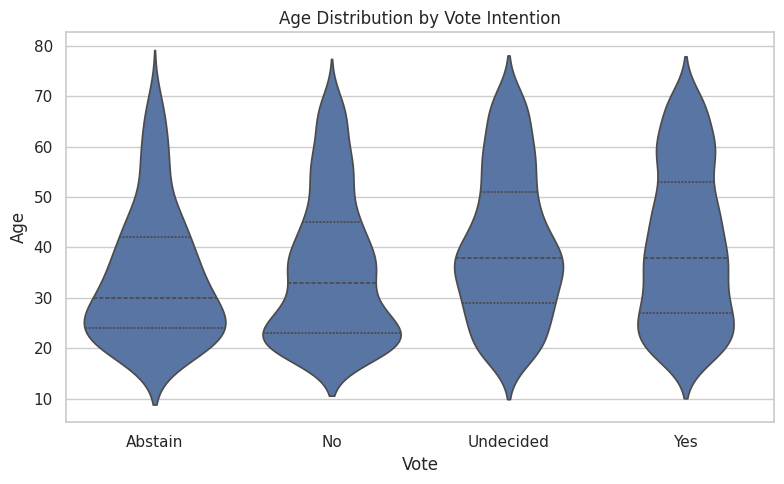

In [28]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_clean, x='vote_label', y='age', order=['Abstain', 'No', 'Undecided', 'Yes'], inner='quartile')
plt.title('Age Distribution by Vote Intention')
plt.xlabel('Vote')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

In [29]:
# Numeric summaries used to interpret the vote-group plots
vote_numeric_summary = df_clean.groupby('vote_label').agg(
    n=('vote_label', 'size'),
    median_income=('income', 'median'),
    mean_income=('income', 'mean'),
    median_log_income=('log_income', 'median'),
    median_statusquo=('statusquo', 'median'),
    mean_statusquo=('statusquo', 'mean'),
    median_age=('age', 'median'),
    mean_age=('age', 'mean')
).round(3)

vote_numeric_summary

,n,median_income,mean_income,median_log_income,median_statusquo,mean_statusquo,median_age,mean_age
vote_label,,,,,,,,
Abstain,187,15000.0,33184.358,9.616,-0.256,-0.190,30.0,34.374
No,889,15000.0,37031.070,9.616,-1.074,-0.911,33.0,35.799
Undecided,588,15000.0,25683.036,9.616,0.085,0.036,38.0,40.365
Yes,868,15000.0,36495.244,9.616,1.177,0.942,38.0,40.371


### Interpretation: numeric variables by vote intention

The group summaries match the plots.

Median income is **15,000 in every vote group**, so the typical income is similar across vote categories. Differences in income are mostly in the upper tail and in the means.

The clearest difference is `statusquo`. The **Yes** group has a much higher median `statusquo` score (**about 1.177**), while the **No** group has a much lower median (**about -1.074**). Abstain and Undecided are closer to the middle.

Overall, `statusquo` is much more informative for vote intention than age or income.


In [30]:
# Non-parametric comparison because income is skewed
income_vote = df_clean[['vote_label', 'income']].dropna()
groups = [group['income'].values for _, group in income_vote.groupby('vote_label')]
kruskal_result = kruskal(*groups)

pd.DataFrame({
    'test': ['Kruskal-Wallis income by vote group'],
    'statistic': [kruskal_result.statistic],
    'p_value': [kruskal_result.pvalue]
}).round(6)

,test,statistic,p_value
0,Kruskal-Wallis income by vote group,31.808044,0.000001


### Interpretation: Kruskal-Wallis test for income by vote

The Kruskal-Wallis test gives **p ≈ 5.74 × 10⁻⁷**, so income distributions differ across vote groups.

This does **not** mean that the group medians are different; the median is **15,000 for every vote group**. Instead, the test is picking up differences in the overall distribution, especially the high-income tail.


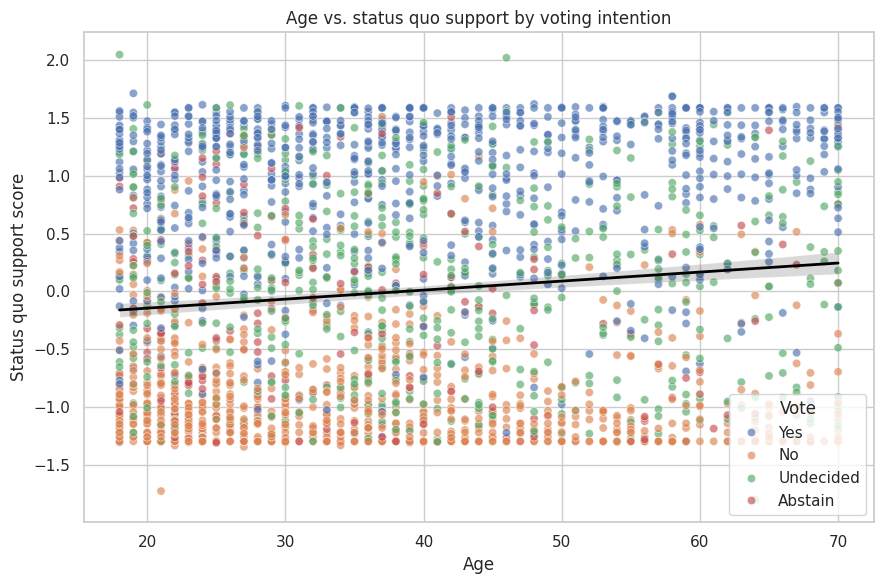

In [31]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_clean, x='age', y='statusquo', hue='vote_label', alpha=0.65)
sns.regplot(data=df_clean, x='age', y='statusquo', scatter=False, color='black', line_kws={'linewidth': 2})
plt.title('Age vs. status quo support by voting intention')
plt.xlabel('Age')
plt.ylabel('Status quo support score')
plt.legend(title='Vote')
plt.tight_layout()
plt.show()

### Comment on the age–statusquo scatter plot

The scatter plot shows only a weak upward trend between age and `statusquo`, which agrees with the small correlation.

The vote colors are more informative than the age trend. **Yes** respondents are mostly at higher `statusquo` values, while **No** respondents are mostly at lower values.


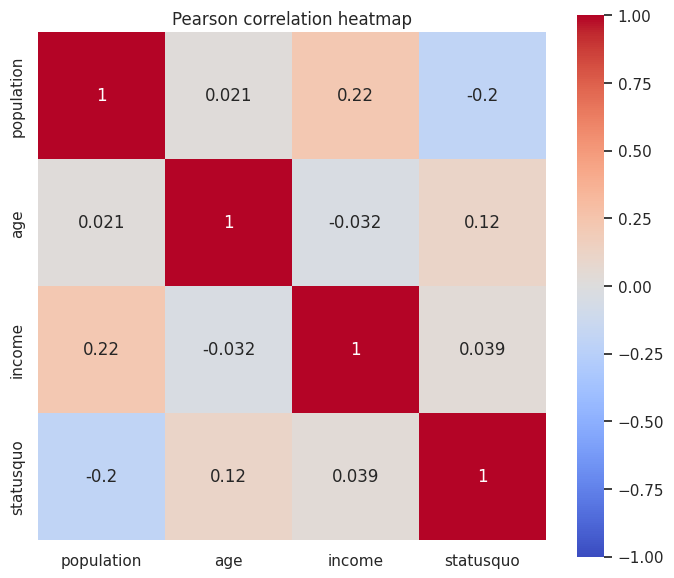

In [32]:
plt.figure(figsize=(7, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Pearson correlation heatmap')
plt.tight_layout()
plt.show()

### Comment on the correlation heatmap

The heatmap confirms that there are no very strong linear correlations among the numeric variables.

This is useful because it prevents overinterpretation. The most important vote-related pattern is not a simple correlation between age, income, and population; it appears more clearly when we compare groups by vote and look at `statusquo`.


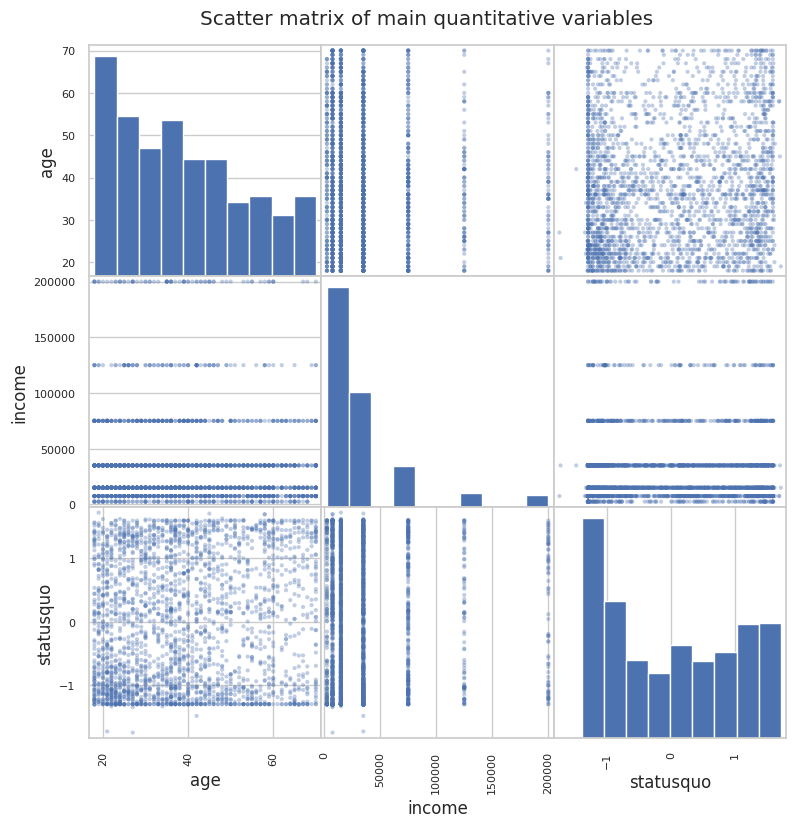

In [33]:
# Scatter matrix for compact multivariate visual inspection
from pandas.plotting import scatter_matrix
plot_df = df_clean[['age', 'income', 'statusquo']].dropna()
axes = scatter_matrix(plot_df, figsize=(9, 9), diagonal='hist', alpha=0.35)
plt.suptitle('Scatter matrix of main quantitative variables', y=0.92)
plt.show()

### Comment on the scatter-matrix plot

The scatter matrix is a quick diagnostic view of the numeric variables.

It confirms three main points: income is skewed, the numeric variables have weak pairwise relationships, and there is no obvious simple straight-line pattern explaining all variables.


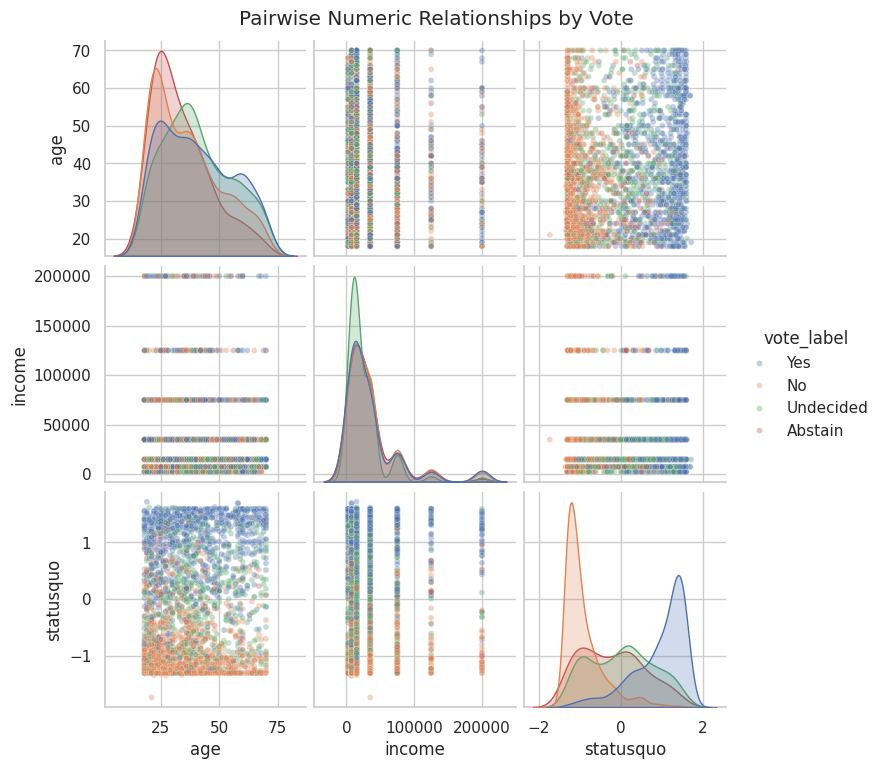

In [34]:
pairplot_df = df_clean[['age', 'income', 'statusquo', 'vote_label']].dropna().copy()

pairgrid = sns.pairplot(
    pairplot_df,
    vars=['age', 'income', 'statusquo'],
    hue='vote_label',
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 18},
    diag_kws={'common_norm': False}
)
pairgrid.fig.suptitle('Pairwise Numeric Relationships by Vote', y=1.02)
plt.show()

### Comment on the pairplot by vote

The pairplot adds vote categories to the numeric relationships.

The clearest separation is along the `statusquo` axis. **Yes** and **No** respondents differ much more by `statusquo` than by age or income. This agrees with the boxplots and later modelling.


## 8. Advanced EDA: Association Rule Mining

Association Rule Mining (ARM) is useful as an exploratory method for finding combinations of respondent attributes that appear together more often than expected. It extends the categorical EDA idea of cross-tabulation to multi-variable patterns.

For ARM, the numeric variables are discretized into categories:

- `age` → age groups
- `income` → low, middle, high income groups
- `statusquo` → opposition-leaning, mixed/neutral, pro-status-quo groups

The goal is not causal inference. The goal is to discover interpretable survey patterns such as:

`{statusquo_group = pro-status-quo, income_group = high} → {vote = Yes}`

In [35]:
# Prepare a transaction-style dataset for Association Rule Mining
arm_df = df_clean.copy()

region_labels = {
    'N': 'North',
    'M': 'Metropolitan',
    'C': 'Central',
    'S': 'South',
    'SA': 'Southern Austral'
}

arm_df['region_group'] = arm_df['region'].map(region_labels)
arm_df['sex_group'] = arm_df['sex_label']
arm_df['education_group'] = arm_df['education_label']
arm_df['vote_group'] = arm_df['vote_label']

arm_df['age_group'] = pd.cut(
    arm_df['age'],
    bins=[17, 29, 44, 59, 100],
    labels=['18-29', '30-44', '45-59', '60+'],
    include_lowest=True
)

arm_df['income_group'] = pd.qcut(
    arm_df['income'],
    q=3,
    labels=['low', 'middle', 'high'],
    duplicates='drop'
)

arm_df['statusquo_group'] = pd.qcut(
    arm_df['statusquo'],
    q=3,
    labels=['opposition-leaning', 'mixed/neutral', 'pro-status-quo'],
    duplicates='drop'
)

arm_vars = [
    'region_group',
    'sex_group',
    'education_group',
    'vote_group',
    'age_group',
    'income_group',
    'statusquo_group'
]

arm_data = arm_df[arm_vars].dropna()

transactions = [
    frozenset(f'{col}={row[col]}' for col in arm_vars)
    for _, row in arm_data.astype(str).iterrows()
]

print('Rows available for ARM after dropping missing values:', len(arm_data))
print('Number of variables used in each transaction:', len(arm_vars))
print()
print('Example transaction:')
print(sorted(next(iter(transactions))))

Rows available for ARM after dropping missing values: 2431
Number of variables used in each transaction: 7

Example transaction:
['age_group=60+', 'education_group=Primary', 'income_group=middle', 'region_group=North', 'sex_group=Male', 'statusquo_group=pro-status-quo', 'vote_group=Yes']


### Interpretation: ARM data preparation

The ARM section uses **2431 complete transactions** after removing rows with missing values in the selected variables.

Each transaction contains seven items: region, sex, education, vote, age group, income group, and statusquo group. Numeric variables are grouped into categories so that association rules can be found.


In [36]:
# Custom frequent-itemset mining for itemsets of size 1, 2, and 3.
# This keeps the ARM section self-contained without requiring a special ARM package.
min_support = 0.03
max_itemset_size = 3
n_transactions = len(transactions)

item_counts = Counter()
for transaction in transactions:
    items = sorted(transaction)
    for size in range(1, max_itemset_size + 1):
        for combo in combinations(items, size):
            item_counts[frozenset(combo)] += 1

supports = {
    itemset: count / n_transactions
    for itemset, count in item_counts.items()
    if count / n_transactions >= min_support
}

frequent_itemsets = pd.DataFrame([
    {
        'itemset': ', '.join(sorted(itemset)),
        'size': len(itemset),
        'count': item_counts[itemset],
        'support': support
    }
    for itemset, support in supports.items()
]).sort_values(['size', 'support'], ascending=[True, False]).reset_index(drop=True)

print('Minimum support threshold:', min_support)
print('Number of frequent itemsets found:', len(frequent_itemsets))
frequent_itemsets.head(15)

Minimum support threshold: 0.03
Number of frequent itemsets found: 678


,itemset,size,count,support
0,income_group=low,1,1328,0.546277
1,sex_group=Female,1,1250,0.514192
2,sex_group=Male,1,1181,0.485808
3,education_group=Secondary,1,1010,0.415467
4,education_group=Primary,1,1002,0.412176
5,vote_group=No,1,867,0.356643
6,age_group=18-29,1,850,0.349650
7,region_group=Southern Austral,1,848,0.348828
8,vote_group=Yes,1,836,0.343891
9,statusquo_group=opposition-leaning,1,833,0.342657


### Interpretation: frequent itemsets

With minimum support set to **3%**, the notebook finds **678 frequent itemsets**.

This means there are many combinations of respondent characteristics that appear often enough to analyze. Common items include low income, sex groups, primary/secondary education, and Yes/No vote groups.


In [37]:
# Generate association rules where the consequent is a voting intention.
# Metrics:
# - support: P(antecedent and consequent)
# - confidence: P(consequent | antecedent)
# - lift: confidence / P(consequent), so values above 1 indicate stronger-than-baseline association
# - leverage: observed support minus expected support under independence
# - conviction: another directional rule-strength measure

min_confidence = 0.35
min_lift = 1.10

rule_rows = []
for itemset, itemset_support in supports.items():
    if len(itemset) < 2:
        continue

    for consequent_item in itemset:
        if not consequent_item.startswith('vote_group='):
            continue

        antecedent = itemset - {consequent_item}

        # Do not use one vote category to predict another vote category.
        if any(item.startswith('vote_group=') for item in antecedent):
            continue

        antecedent_support = item_counts[antecedent] / n_transactions
        consequent_support = item_counts[frozenset({consequent_item})] / n_transactions
        confidence = itemset_support / antecedent_support
        lift = confidence / consequent_support
        leverage = itemset_support - antecedent_support * consequent_support
        conviction = np.inf if np.isclose(confidence, 1) else (1 - consequent_support) / (1 - confidence)

        if confidence >= min_confidence and lift >= min_lift:
            rule_rows.append({
                'antecedents': ', '.join(sorted(antecedent)),
                'consequent': consequent_item,
                'support': itemset_support,
                'confidence': confidence,
                'lift': lift,
                'leverage': leverage,
                'conviction': conviction,
                'antecedent_support': antecedent_support,
                'consequent_support': consequent_support
            })

vote_rules = pd.DataFrame(rule_rows).sort_values(
    ['lift', 'confidence', 'support'],
    ascending=False
).reset_index(drop=True)

print('Minimum confidence threshold:', min_confidence)
print('Minimum lift threshold:', min_lift)
print('Number of vote-prediction rules found:', len(vote_rules))

vote_rules_display = vote_rules.copy()
metric_cols = ['support', 'confidence', 'lift', 'leverage', 'conviction', 'antecedent_support', 'consequent_support']
vote_rules_display[metric_cols] = vote_rules_display[metric_cols].round(3)
vote_rules_display.head(15)

Minimum confidence threshold: 0.35
Minimum lift threshold: 1.1
Number of vote-prediction rules found: 94


,antecedents,consequent,support,confidence,lift,leverage,conviction,antecedent_support,consequent_support
0,"education_group=Post-secondary, statusquo_grou...",vote_group=Yes,0.042,0.894,2.599,0.026,6.178,0.046,0.344
1,"education_group=Post-secondary, statusquo_grou...",vote_group=No,0.069,0.898,2.517,0.041,6.298,0.077,0.357
2,"income_group=high, statusquo_group=pro-status-quo",vote_group=Yes,0.055,0.847,2.463,0.033,4.292,0.065,0.344
3,"region_group=North, statusquo_group=pro-status...",vote_group=Yes,0.042,0.828,2.407,0.024,3.812,0.050,0.344
4,"income_group=high, statusquo_group=opposition-...",vote_group=No,0.048,0.854,2.395,0.028,4.407,0.056,0.357
5,"sex_group=Male, statusquo_group=opposition-lea...",vote_group=No,0.153,0.845,2.370,0.088,4.153,0.181,0.357
6,"age_group=60+, statusquo_group=pro-status-quo",vote_group=Yes,0.043,0.814,2.367,0.025,3.527,0.053,0.344
7,"age_group=45-59, statusquo_group=pro-status-quo",vote_group=Yes,0.057,0.813,2.364,0.033,3.506,0.070,0.344
8,"age_group=18-29, statusquo_group=opposition-le...",vote_group=No,0.114,0.829,2.324,0.065,3.759,0.137,0.357
9,"region_group=Southern Austral, statusquo_group...",vote_group=Yes,0.067,0.792,2.304,0.038,3.158,0.085,0.344


### Interpretation: vote-prediction association rules

The ARM analysis finds **94 rules** where the consequence is a vote category.

The strongest rules mostly include `statusquo_group`, which matches the earlier plots. For example:

- **Post-secondary + pro-status-quo → Yes** has confidence about **0.894** and lift about **2.599**.
- **Post-secondary + opposition-leaning → No** has confidence about **0.898** and lift about **2.517**.

A lift greater than 1 means the vote outcome is more common in that group than in the full sample. These are useful patterns, but they are **associations, not proof of causation**.


In [38]:
# Rules without statusquo are less politically direct and help reveal demographic patterns.
rules_without_statusquo = vote_rules[
    ~vote_rules['antecedents'].str.contains('statusquo_group=', regex=False)
].copy()

rules_without_statusquo_display = rules_without_statusquo.copy()
rules_without_statusquo_display[metric_cols] = rules_without_statusquo_display[metric_cols].round(3)
rules_without_statusquo_display.head(10)

,antecedents,consequent,support,confidence,lift,leverage,conviction,antecedent_support,consequent_support
39,"education_group=Post-secondary, sex_group=Male",vote_group=No,0.055,0.570,1.599,0.021,1.497,0.097,0.357
40,"age_group=18-29, education_group=Post-secondary",vote_group=No,0.042,0.563,1.578,0.016,1.472,0.075,0.357
41,"education_group=Post-secondary, income_group=m...",vote_group=No,0.037,0.549,1.540,0.013,1.428,0.067,0.357
42,"region_group=North, sex_group=Female",vote_group=Yes,0.034,0.522,1.518,0.012,1.373,0.065,0.344
43,education_group=Post-secondary,vote_group=No,0.090,0.525,1.472,0.029,1.355,0.172,0.357
44,"age_group=18-29, sex_group=Male",vote_group=No,0.090,0.520,1.459,0.028,1.341,0.173,0.357
45,"education_group=Post-secondary, region_group=S...",vote_group=No,0.038,0.514,1.441,0.012,1.323,0.074,0.357
46,"age_group=30-44, education_group=Post-secondary",vote_group=No,0.035,0.512,1.435,0.011,1.318,0.069,0.357
47,"education_group=Primary, region_group=South",vote_group=Yes,0.062,0.484,1.407,0.018,1.271,0.128,0.344
48,"region_group=Central, sex_group=Male",vote_group=No,0.056,0.484,1.357,0.015,1.247,0.115,0.357


### Interpretation: demographic-only ARM rules

When `statusquo_group` is removed from the rules, the remaining demographic-only rules are weaker.

The strongest one is **Post-secondary + Male → No**, with confidence about **0.570** and lift about **1.599**.

This means demographics do contain some signal, but `statusquo_group` is clearly more informative for vote intention.


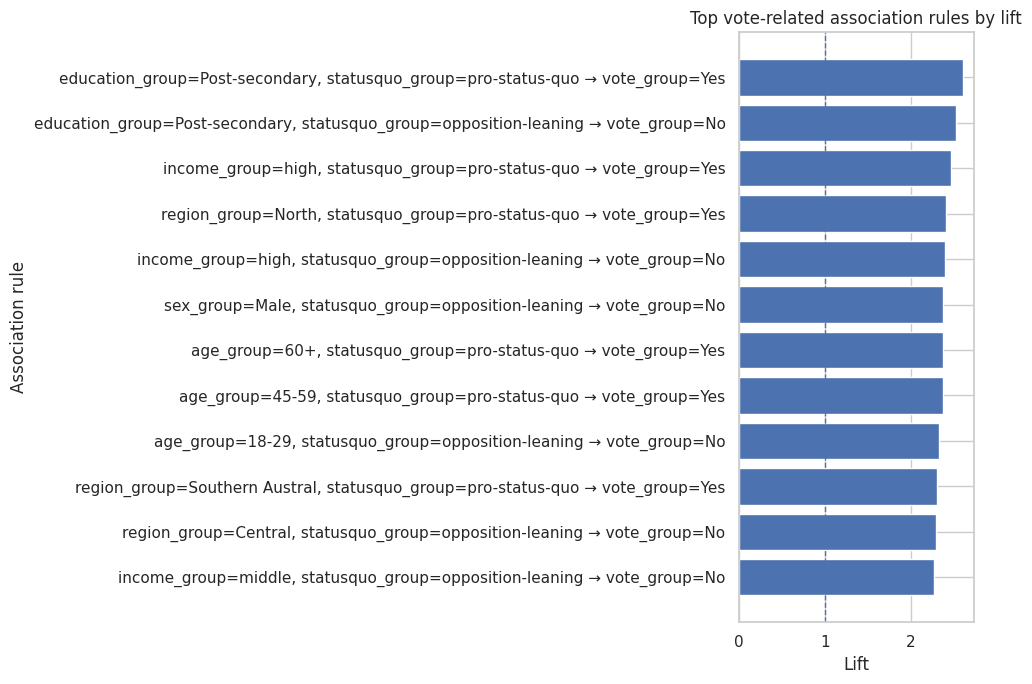

In [39]:
# Visualize the strongest vote-related association rules by lift.
top_rules = vote_rules.head(12).copy()
top_rules['rule'] = top_rules['antecedents'] + ' → ' + top_rules['consequent']

top_rules_plot = top_rules.sort_values('lift', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_rules_plot['rule'], top_rules_plot['lift'])
plt.axvline(1, linestyle='--', linewidth=1)
plt.xlabel('Lift')
plt.ylabel('Association rule')
plt.title('Top vote-related association rules by lift')
plt.tight_layout()
plt.show()

### Comment on the top-rule bar chart

The bar chart ranks the strongest association rules by lift.

Rules with lift above 1 are stronger than random independence. The top rules have lift above 2, which means the vote outcome is more than twice as common in those groups compared with the overall vote rate.


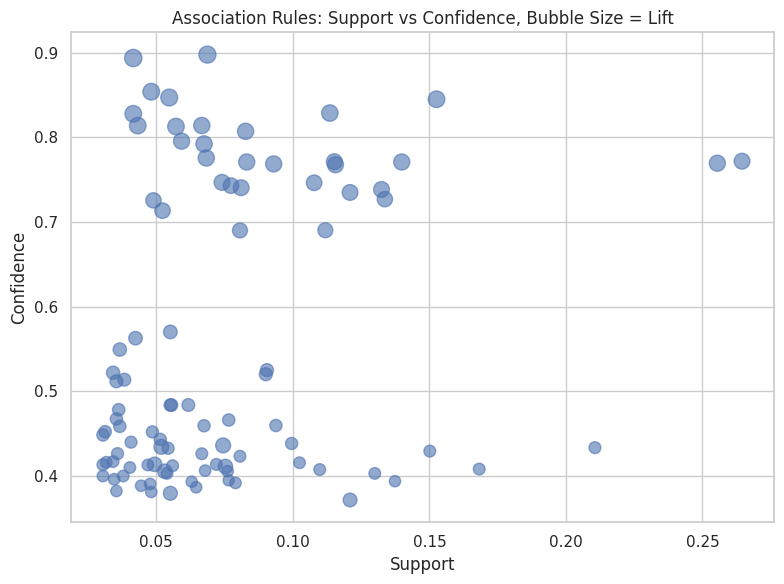

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(
    vote_rules['support'],
    vote_rules['confidence'],
    s=vote_rules['lift'] * 60,
    alpha=0.6
)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence, Bubble Size = Lift')
plt.tight_layout()
plt.show()

### Comment on the ARM bubble plot

The bubble plot shows three rule measures at once:

- x-axis = support, or how common the rule is
- y-axis = confidence, or how often the rule is correct within that group
- bubble size = lift, or how much stronger the rule is than random baseline

The strongest rules have high confidence and high lift, but only moderate support. That is normal: very specific patterns often apply to smaller parts of the sample.


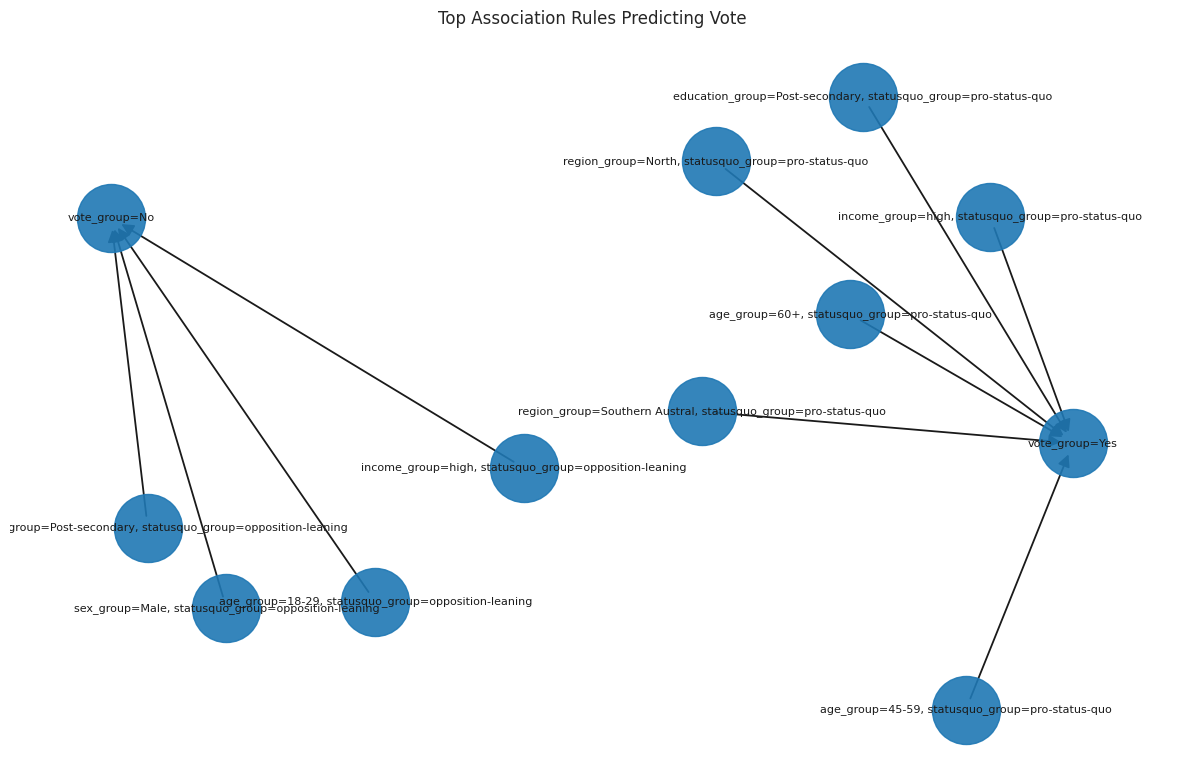

In [41]:
top_network_rules = vote_rules.sort_values('lift', ascending=False).head(10).copy()

G = nx.DiGraph()
for _, row in top_network_rules.iterrows():
    antecedent = row['antecedents']
    consequent = row['consequent']
    G.add_edge(antecedent, consequent, weight=row['lift'])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=RANDOM_STATE, k=1.2)
nx.draw_networkx_nodes(G, pos, node_size=2400, alpha=0.9)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=18, width=1.3)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title('Top Association Rules Predicting Vote')
plt.axis('off')
plt.tight_layout()
plt.show()

### Comment on the ARM network graph

The network graph makes the rule structure easier to read.

Most strong links connect statusquo-related groups to either **Yes** or **No**. This supports the main finding: the most informative ARM patterns involve statusquo orientation, not random demographic combinations.


## 9. Advanced modelling extension

EDA usually comes before modelling, but a small model can help summarize which variables are most strongly associated with the outcome.

Here, I focus on respondents who answered `Yes` or `No`, excluding `Abstain` and `Undecided`, and model the probability of a `Yes` vote.

In [42]:
yn = df_clean[df_clean['vote'].isin(['Y', 'N'])].copy()
yn['vote_yes'] = (yn['vote'] == 'Y').astype(int)

print('Yes/No modelling dataset shape:', yn.shape)
yn[['vote_label', 'age', 'income', 'log_income', 'statusquo', 'sex_label', 'education_label', 'region']].head()

Yes/No modelling dataset shape: (1757, 13)


,vote_label,age,income,log_income,statusquo,sex_label,education_label,region
0,Yes,65.0,35000.0,10.463132,1.00820,Male,Primary,N
1,No,29.0,7500.0,8.922792,-1.29617,Male,Post-secondary,N
2,Yes,38.0,15000.0,9.615872,1.23072,Female,Primary,N
3,No,49.0,35000.0,10.463132,-1.03163,Female,Primary,N
4,No,23.0,35000.0,10.463132,-1.10496,Female,Secondary,N


### Interpretation: modelling sample

The logistic model uses only respondents who answered **Yes** or **No**. This gives **1757 observations**.

Undecided, Abstain, and missing vote responses are excluded because logistic regression here needs a two-category outcome. The split is almost balanced: **868 Yes** and **889 No**, which makes the evaluation easier to interpret.


In [43]:
# Logistic regression with interpretable coefficients
logit_model = smf.logit(
    formula='vote_yes ~ age + log_income + statusquo + C(sex_label) + C(education_label) + C(region)',
    data=yn
).fit(disp=False)

coef_table = logit_model.summary2().tables[1]
coef_table['odds_ratio'] = np.exp(coef_table['Coef.'])
coef_table[['Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]', 'odds_ratio']].round(4)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],odds_ratio
Intercept,0.4813,1.3510,0.3562,0.7217,-2.1667,3.1293,1.6181
C(sex_label)[T.Male],-0.5698,0.2032,-2.8045,0.0050,-0.9680,-0.1716,0.5657
C(education_label)[T.Primary],1.0406,0.3508,2.9665,0.0030,0.3531,1.7281,2.8309
C(education_label)[T.Secondary],0.3745,0.3024,1.2383,0.2156,-0.2183,0.9672,1.4542
C(region)[T.M],0.6384,0.5921,1.0782,0.2809,-0.5221,1.7990,1.8935
C(region)[T.N],-0.0652,0.3578,-0.1822,0.8554,-0.7664,0.6361,0.9369
C(region)[T.S],-0.3007,0.2927,-1.0273,0.3043,-0.8744,0.2730,0.7403
C(region)[T.SA],-0.1346,0.2792,-0.4823,0.6296,-0.6819,0.4126,0.8740
age,0.0005,0.0075,0.0699,0.9442,-0.0141,0.0152,1.0005
log_income,-0.0422,0.1194,-0.3537,0.7235,-0.2762,0.1918,0.9586


### Interpretation: logistic regression coefficients

The logistic regression supports the EDA results.

`statusquo` is the strongest predictor. Its odds ratio is about **24.37**, with **p < 0.001**. In simple terms, higher `statusquo` scores are strongly associated with higher odds of a **Yes** vote, after accounting for age, income, sex, education, and region.

Some demographic variables also matter, but less strongly. Male respondents have lower estimated odds of **Yes** than female respondents (**odds ratio ≈ 0.566**, **p = 0.005**). Primary education has higher estimated odds of **Yes** than Post-secondary education (**odds ratio ≈ 2.831**, **p = 0.003**).

Age, log income, and region are not statistically significant after the other variables are included. This agrees with the visual EDA: demographics show some patterns, but `statusquo` is the dominant signal.


In [44]:
# Predictive evaluation with a train/test split
features = ['age', 'income', 'statusquo', 'sex_label', 'education_label', 'region']
target = 'vote_yes'

X = yn[features]
y = yn[target]

numeric_features = ['age', 'income', 'statusquo']
categorical_features = ['sex_label', 'education_label', 'region']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

eval_table = pd.DataFrame({
    'accuracy': [accuracy_score(y_test, y_pred)],
    'roc_auc': [roc_auc_score(y_test, y_prob)]
})

display(eval_table.round(4))
print('Confusion matrix:')
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes']))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

,accuracy,roc_auc
0,0.9091,0.9649


Confusion matrix:


,Predicted No,Predicted Yes
Actual No,202,21
Actual Yes,19,198



Classification report:
              precision    recall  f1-score   support

          No       0.91      0.91      0.91       223
         Yes       0.90      0.91      0.91       217

    accuracy                           0.91       440
   macro avg       0.91      0.91      0.91       440
weighted avg       0.91      0.91      0.91       440



### Interpretation: predictive evaluation

The model performs well on the test set: **accuracy ≈ 0.909** and **ROC AUC ≈ 0.965**.

The confusion matrix is also balanced. The model correctly classifies **202 No** and **198 Yes** cases, while misclassifying **21 No** and **19 Yes** cases.

This does not prove causation. It simply shows that the variables, especially `statusquo`, are very useful for predicting Yes vs. No responses in this dataset.


## 10. Main conclusions

1. **Income is strongly right-skewed.** The mean income is about **33,876**, while the median and mode are both **15,000**. The histogram, boxplot, skewness, kurtosis, and outlier count all support this.

2. **Missing data is present but not severe.** The largest missingness is in `vote` (**6.22%**) and `income` (**3.63%**). These values are important to mention, but they do not prevent the EDA.

3. **Education and vote intention are related.** Post-secondary respondents have a higher **No** share, while Primary respondents have higher **Yes** and **Undecided** shares. The chi-square test confirms the relationship, but Cramér's V shows it is only small to moderate.

4. **`statusquo` is the clearest vote-related variable.** The boxplots, pairplot, ARM rules, and logistic regression all point to the same pattern: higher `statusquo` values are associated with **Yes**, while lower values are associated with **No**.

5. **Numeric correlations are mostly weak.** Age, income, population, and statusquo do not show strong simple pairwise correlations. The vote-related pattern becomes clearer when comparing groups and using models.

6. **Association Rule Mining is a useful advanced EDA addition.** ARM finds **94 vote-prediction rules**. The strongest rules involve `statusquo_group`; demographic-only rules are weaker.

7. **The logistic model supports the EDA.** The Yes/No model reaches about **90.9% accuracy** and **0.965 ROC AUC**. This should be interpreted as predictive association, not proof of causation.


## Colab reproducibility note

This notebook is self-contained for Google Colab. It checks required packages and loads the Chile dataset from a public URL when the local CSV is absent.

To keep a copy of the completed work from Colab, use **File → Download → Download .ipynb** or **File → Print → Save as PDF**.
